# Introduction

The objective of this task is to segment customers based on their spending behavior using unsupervised machine learning techniques.

We aim to:
- Explore customer data
- Apply K-Means clustering
- Visualize clusters using PCA
- Suggest marketing strategies for each customer segment

# Dataset Description

The dataset contains customer information such as:

- CustomerID
- Gender
- Age
- Annual Income
- Spending Score

The goal is to identify meaningful customer groups based on spending patterns.

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Display basic info
print(df.shape)
print(df.columns)

df.head()

(200, 5)
Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Data Cleaning

- Checked for missing values
- Dataset was already clean
- Selected relevant numerical features for clustering

In [ ]:
# Missing values
print(df.isnull().sum())

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


# Exploratory Data Analysis

We visualize customer income, age, and spending behavior.

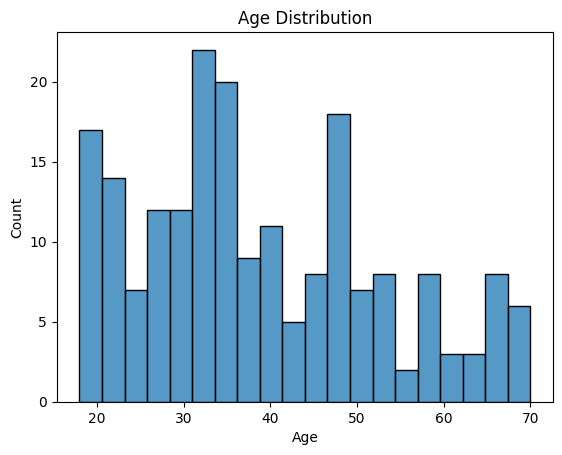

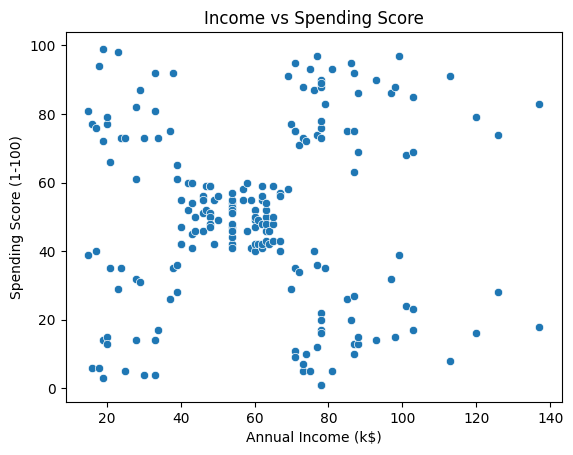

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Age distribution
sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

# Income vs Spending Score
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df)
plt.title("Income vs Spending Score")
plt.show()

The visualizations show different customer spending behaviors. Some customers have high income and high spending scores, while others spend less despite higher income.

# K-Means Clustering

We apply K-Means clustering to group customers based on income and spending score.

In [ ]:
from sklearn.cluster import KMeans

# Select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Apply KMeans
kmeans = KMeans(n_clusters=5, random_state=42)

# Predict clusters
df['Cluster'] = kmeans.fit_predict(X)

# Show data
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


# Cluster Visualization

The following graph visualizes customer clusters.

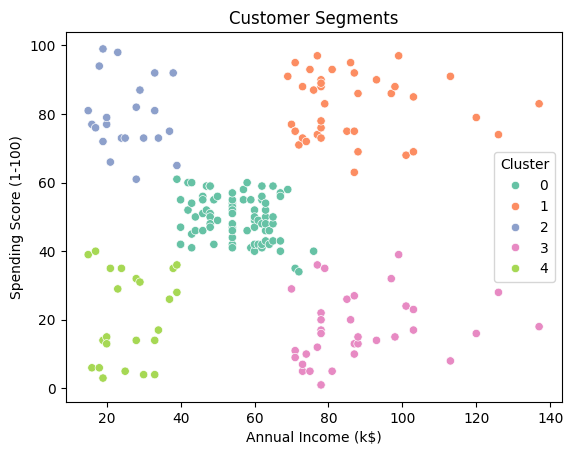

In [ ]:
# Plot clusters
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='Set2'
)

plt.title("Customer Segments")
plt.show()

# PCA Visualization

PCA is used to reduce dimensions and visualize clusters more effectively.

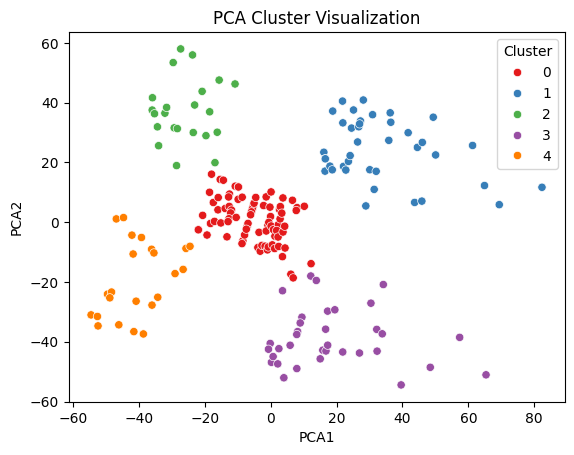

In [ ]:
from sklearn.decomposition import PCA

# PCA transformation
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

# Create PCA dataframe
pca_df = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])

pca_df['Cluster'] = df['Cluster']

# Plot PCA clusters
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=pca_df,
    palette='Set1'
)

plt.title("PCA Cluster Visualization")
plt.show()

# Marketing Strategies

Different strategies can be applied to each customer segment:

- High Income & High Spending:
  Premium offers and loyalty rewards

- High Income & Low Spending:
  Personalized discounts and promotions

- Low Income & High Spending:
  Budget-friendly bundles and deals

- Low Income & Low Spending:
  Awareness campaigns and engagement offers

# Conclusion

K-Means clustering successfully grouped customers based on spending behavior.

The analysis helps businesses:
- Understand customer segments
- Create targeted marketing strategies
- Improve customer engagement and sales